In [43]:
from utils import get_class_imbalance, preprocessing
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [44]:
l, m, h = get_class_imbalance('train.csv')

Proportion of low: 58.852380952380955%
Propostion of high: 3.338095238095238%
Proportion of Medium: 37.80952380952381%


In [48]:
X, Y = preprocessing('train.csv')
cols = X.columns.tolist()

In [49]:
X, X_test, Y, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [5]:
X

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Water_Source_Groundwater,Water_Source_Reservoir,Water_Source_Rainwater,Mulching_Used_No,Mulching_Used_Yes,Region_East,Region_North,Region_West,Region_Central,Region_South
38991,4.82,59.48,0.36,0.26,12.30,33.44,629.05,5.93,3.26,9.46,...,False,False,True,False,True,False,False,True,False,False
43897,5.45,11.61,1.41,1.93,19.43,56.29,1586.61,6.22,13.86,7.91,...,False,False,False,True,False,True,False,False,False,False
17962,5.52,30.99,0.49,2.57,12.07,74.48,1561.57,10.44,7.57,6.66,...,False,True,False,False,True,False,False,True,False,False
47622,6.59,24.88,1.31,2.21,37.51,86.66,954.42,8.13,12.26,5.08,...,True,False,False,False,True,True,False,False,False,False
9006,5.18,33.64,0.83,1.24,39.99,64.87,1071.06,7.73,9.69,7.49,...,False,False,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62570,7.31,63.68,0.99,1.62,18.52,41.17,755.35,7.86,15.32,6.01,...,False,False,False,False,True,False,False,True,False,False
38158,6.46,8.69,0.68,0.54,22.71,75.71,974.00,6.59,8.39,1.71,...,False,False,False,False,True,False,False,False,False,True
860,7.07,47.12,0.87,2.65,19.39,56.81,721.15,10.31,1.46,8.97,...,True,False,False,False,True,False,False,False,False,True
15795,5.85,33.88,0.64,2.66,26.50,52.34,1806.23,5.88,15.95,3.91,...,False,False,False,False,True,True,False,False,False,False


In [50]:
# Convert the data into numpy

X = X.to_numpy()
Y = Y.to_numpy()
X_test = X_test.to_numpy()
Y_test = Y_test.to_numpy()

In [51]:
X = torch.tensor(X.astype(float), dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.float32)
X_test = torch.tensor(X_test.astype(float), dtype=torch.float32)
Y_test = torch.tensor(Y_test.astype(float), dtype=torch.float32)

In [8]:
colinearity = torch.corrcoef(X.T)

In [52]:
from torchmetrics.functional import pearson_corrcoef

corrs = []

for i in range(X.shape[1]):
    corr_0 = pearson_corrcoef(X[:, i], Y[:, 0])
    corr_1 = pearson_corrcoef(X[:, i], Y[:, 1])
    corr_2 = pearson_corrcoef(X[:, i], Y[:, 2])
    corr = torch.max(torch.max(corr_0, corr_1), corr_2)
    corrs.append(corr)


In [54]:
corrs_tensor = torch.tensor(corrs)

In [11]:
corr_i = torch.where(corrs_tensor > torch.mean(corrs_tensor), 1, 0)

In [55]:
corr_i

tensor([0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0])

In [56]:
X = X[:, corr_i.bool()]


In [57]:
significant = []
for i in range(corr_i.shape[0]):
    if corr_i[i] == 1:
        significant.append(cols[i])

In [60]:
# Recall from linea regression

ones = torch.ones(X.shape[0]).unsqueeze(-1)
X_arr = torch.cat([ones, X], -1)
Beta = torch.inverse(X_arr.T@X_arr + 0.05 * torch.eye(X_arr.shape[1]))@X_arr.T@Y

In [61]:
Beta

tensor([[ 5.6572e-01,  5.9219e-02, -3.4840e-02],
        [ 1.1367e-03, -3.2051e-04,  1.2310e-04],
        [-1.0043e-03,  1.4218e-03, -3.9884e-04],
        [-6.9803e-04, -5.8083e-03,  1.6193e-03],
        [-4.5527e-01,  3.9010e-01,  8.4891e-02],
        [-2.0785e-01,  1.4561e-01,  6.2095e-02],
        [-1.5178e-01, -2.3383e-01,  3.8407e-01],
        [-2.6460e-01,  2.4447e-01,  2.1460e-02],
        [-7.9349e-02,  2.3433e-01, -5.4851e-03],
        [-8.5304e-02,  2.4921e-01, -4.1471e-03],
        [ 3.7765e-01, -1.7193e-01, -4.4991e-02],
        [ 3.6777e-01, -1.7425e-01, -3.9220e-02],
        [ 1.0217e-01,  1.2807e-01,  2.9251e-02],
        [ 3.3745e-01, -7.1517e-02, -8.5173e-03]])

In [62]:
X_arr @ Beta

tensor([[ 0.8708,  0.2164, -0.0398],
        [ 0.3097,  0.5933,  0.0719],
        [ 1.2888, -0.2233, -0.0713],
        ...,
        [ 0.8509,  0.2409, -0.0471],
        [ 0.5600,  0.4007, -0.0080],
        [-0.3726,  1.1962,  0.1592]])

In [64]:
Y

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        ...,
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 0., 1.]])

In [65]:
pred = torch.softmax(X_arr @ Beta, 1)

In [66]:
pred

tensor([[0.5203, 0.2704, 0.2093],
        [0.3209, 0.4261, 0.2530],
        [0.6770, 0.1493, 0.1737],
        ...,
        [0.5126, 0.2785, 0.2088],
        [0.4133, 0.3525, 0.2342],
        [0.1333, 0.6399, 0.2268]])

In [67]:
final = pred.argmax(dim=1)

In [68]:
final

tensor([0, 1, 0,  ..., 0, 0, 1])

In [ ]:
class LogisticRegression(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.linear = nn.Linear(in_features, num_classes, bias=False)

    def forward(self, x):
        return self.linear(x)

model = LogisticRegression(X_arr.shape[1], Y.shape[1])
logits = model(X_arr)
probs = torch.softmax(logits, dim=1)
probs

tensor([[2.6049e-01, 7.3951e-01, 3.9486e-11],
        [1.7474e-02, 9.8022e-01, 2.3032e-03],
        [5.6791e-02, 9.4321e-01, 1.8371e-06],
        ...,
        [4.7876e-01, 5.2124e-01, 6.9706e-09],
        [1.1513e-02, 9.8849e-01, 3.0342e-07],
        [1.2075e-01, 8.7075e-01, 8.5043e-03]], grad_fn=<SoftmaxBackward0>)

In [70]:
# Now we can train our model. Let's define cross entropy loss 
# (there is a default torch function for it which is safer if you want to investigate)

class CrossEntropyLoss(nn.Module):
    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)
        log_probs = torch.log(probs)
        loss = -torch.sum(targets * log_probs) / logits.shape[0]
        return loss


In [71]:
criterion = CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3)

In [26]:
# Prepare X_test the same way as X (feature filter + ones column)
X_test_filtered = X_test[:, corr_i.bool()]
ones_test = torch.ones(X_test_filtered.shape[0]).unsqueeze(-1)
X_test_arr = torch.cat([ones_test, X_test_filtered], -1)

train_accs = []
val_accs = []
epochs = 10_000
for epoch in range(epochs):
    logits = model(X_arr)
    loss = criterion(logits, Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        preds = logits.argmax(dim=1)
        labels = Y.argmax(dim=1)
        train_acc = (preds == labels).float().mean().item()
        train_accs.append(train_acc)

        with torch.no_grad():
            val_logits = model(X_test_arr)
            val_preds = val_logits.argmax(dim=1)
            val_labels = Y_test.argmax(dim=1)
            val_acc = (val_preds == val_labels).float().mean().item()
            val_accs.append(val_acc)

    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

Epoch 1000/10000 - Loss: 0.6351 - Train Acc: 0.7105 - Val Acc: 0.7048
Epoch 2000/10000 - Loss: 0.5906 - Train Acc: 0.7405 - Val Acc: 0.7358
Epoch 3000/10000 - Loss: 0.5556 - Train Acc: 0.7674 - Val Acc: 0.7623
Epoch 4000/10000 - Loss: 0.5270 - Train Acc: 0.7877 - Val Acc: 0.7825
Epoch 5000/10000 - Loss: 0.5033 - Train Acc: 0.8041 - Val Acc: 0.7987
Epoch 6000/10000 - Loss: 0.4834 - Train Acc: 0.8169 - Val Acc: 0.8118
Epoch 7000/10000 - Loss: 0.4665 - Train Acc: 0.8279 - Val Acc: 0.8225
Epoch 8000/10000 - Loss: 0.4519 - Train Acc: 0.8363 - Val Acc: 0.8312
Epoch 9000/10000 - Loss: 0.4392 - Train Acc: 0.8445 - Val Acc: 0.8406
Epoch 10000/10000 - Loss: 0.4281 - Train Acc: 0.8509 - Val Acc: 0.8455


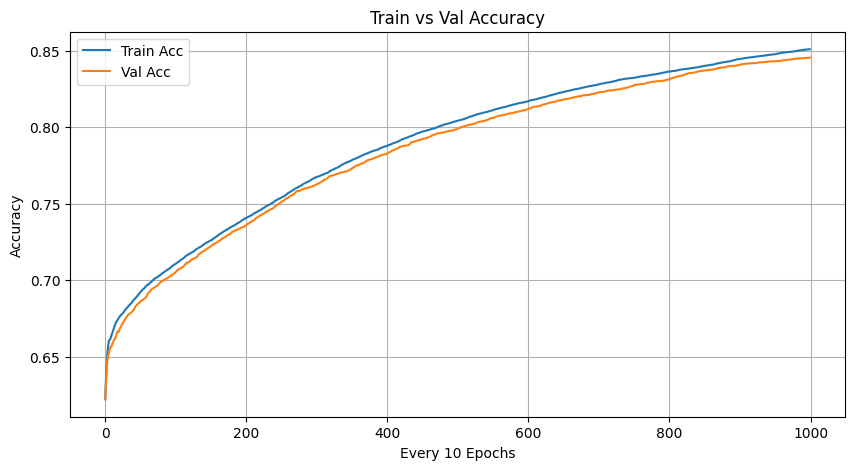

Final Train Acc: 0.8509
Final Val Acc: 0.8455


In [27]:
plt.figure(figsize=(10, 5))
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Every 10 Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs Val Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Train Acc: {train_accs[-1]:.4f}")
print(f"Final Val Acc: {val_accs[-1]:.4f}")

In [37]:
class ManuLoss(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        n_plus = torch.sum(targets, dim=0) # dim (Classes)
        n_minus = targets.shape[0] - n_plus
        log_probs = torch.log_softmax(logits, dim=-1) # dim (Batch x Classes)
        ce_term = - torch.sum(targets * log_probs, dim=0)
        n_log_probs = torch.log((1 - torch.softmax(logits, dim=-1)).clamp(min=1e-7))
        n_ce_term = - torch.sum((1 - targets) * n_log_probs, dim=0)
        loss = (1 / targets.shape[1]) * torch.sum((ce_term / n_plus) + (n_ce_term / n_minus))
        return loss

In [40]:
criterion_m = ManuLoss()
model_v2 = LogisticRegression(X_arr.shape[1], Y.shape[1])
optimizer_m = optim.SGD(model_v2.parameters(), lr=1e-3)

In [41]:
train_accs = []
val_accs = []
epochs = 10_000
for epoch in range(epochs):
    logits = model_v2(X_arr)
    loss = criterion_m(logits, Y)

    optimizer_m.zero_grad()
    loss.backward()
    optimizer_m.step()

    if (epoch + 1) % 10 == 0:
        preds = logits.argmax(dim=1)
        labels = Y.argmax(dim=1)
        train_acc = (preds == labels).float().mean().item()
        train_accs.append(train_acc)

        with torch.no_grad():
            val_logits = model_v2(X_test_arr)
            val_preds = val_logits.argmax(dim=1)
            val_labels = Y_test.argmax(dim=1)
            val_acc = (val_preds == val_labels).float().mean().item()
            val_accs.append(val_acc)
        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

Epoch 1000/10000 - Loss: 1.0402 - Train Acc: 0.6109 - Val Acc: 0.6081
Epoch 2000/10000 - Loss: 0.9835 - Train Acc: 0.6499 - Val Acc: 0.6467
Epoch 3000/10000 - Loss: 0.9367 - Train Acc: 0.6816 - Val Acc: 0.6816
Epoch 4000/10000 - Loss: 0.8975 - Train Acc: 0.7089 - Val Acc: 0.7097
Epoch 5000/10000 - Loss: 0.8641 - Train Acc: 0.7318 - Val Acc: 0.7322
Epoch 6000/10000 - Loss: 0.8353 - Train Acc: 0.7490 - Val Acc: 0.7501
Epoch 7000/10000 - Loss: 0.8102 - Train Acc: 0.7641 - Val Acc: 0.7643
Epoch 8000/10000 - Loss: 0.7880 - Train Acc: 0.7770 - Val Acc: 0.7772
Epoch 9000/10000 - Loss: 0.7682 - Train Acc: 0.7870 - Val Acc: 0.7867
Epoch 10000/10000 - Loss: 0.7503 - Train Acc: 0.7957 - Val Acc: 0.7952


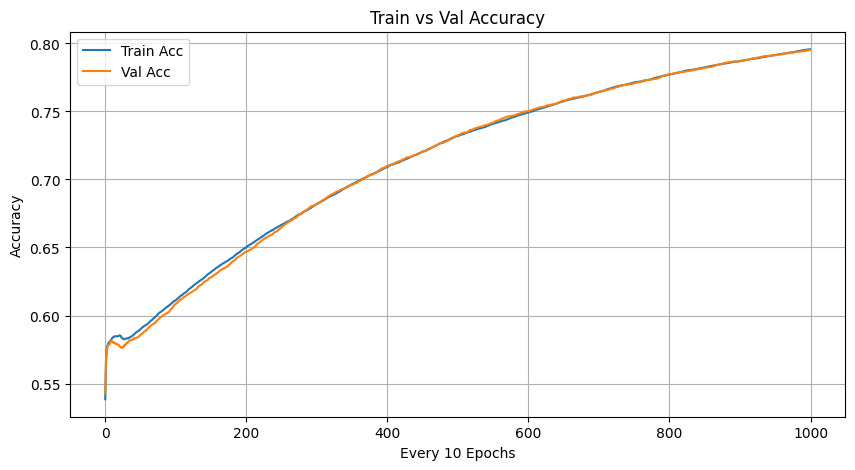

Final Train Acc: 0.7957
Final Val Acc: 0.7952


In [42]:
plt.figure(figsize=(10, 5))
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Every 10 Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs Val Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Train Acc: {train_accs[-1]:.4f}")
print(f"Final Val Acc: {val_accs[-1]:.4f}")

# Exercises

---

## Theory Questions

### Exercise 1: Logistic Regression vs Linear Regression
1. Why can't we use linear regression directly for classification? What goes wrong with the output range?
2. What is the role of the **softmax** function in multiclass logistic regression? Write the softmax formula for class $k$:

$$P(y = k \mid x) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

3. What do the outputs of softmax guarantee that raw logits ($z = Wx + b$) do not?

### Exercise 2: Cross Entropy Loss
1. Write out the cross entropy loss formula for a single sample with one-hot target $y$ and predicted probabilities $\hat{y}$:

$$\mathcal{L} = -\sum_{k=1}^{K} y_k \log(\hat{y}_k)$$

2. Why does cross entropy only "care about" the predicted probability of the **correct** class? (Hint: what happens to terms where $y_k = 0$?)
3. What is the gradient of the cross entropy loss with respect to the logits $z$? Show that it simplifies to $\hat{y} - y$ (softmax output minus one-hot target).

### Exercise 3: Gradient Descent
1. In our training loop, we call `optimizer.zero_grad()`, then `loss.backward()`, then `optimizer.step()`. Explain what each of these three lines does.
2. What happens if you **forget** to call `optimizer.zero_grad()`? Will the model still train? What will go wrong?
3. We used SGD with a learning rate of `1e-3`. What would happen if you set it to `1.0`? What about `1e-8`?

### Exercise 4: Numerical Stability
1. Explain why `torch.log(torch.softmax(logits))` can produce `-inf` or `nan`. Give a concrete example with numbers.
2. How does `log_softmax` (or the `logsumexp` trick) avoid this problem?

---

## Coding Exercises

### Exercise 5: Manual Gradient Descent (No `nn.Module`, no `optim`)
Implement logistic regression training **without** using `nn.Module` or `torch.optim`. Use only raw tensor operations:
- Initialize a weight matrix `W` with `requires_grad=True`
- Compute logits, softmax, and cross entropy loss manually
- Call `.backward()` on the loss to get gradients
- Update `W` using `W.data -= lr * W.grad` and zero the gradients manually

Train for 10,000 epochs and print loss every 1,000 epochs.

In [ ]:
# Exercise 5: Manual Gradient Descent
# Implement logistic regression using only raw tensors — no nn.Module, no optim

# TODO: Initialize W with shape (num_features, num_classes) and requires_grad=True
# W = ...

# TODO: Set learning rate and number of epochs
# lr = ...
# epochs = ...

# TODO: Training loop:
#   1. Compute logits = X_arr @ W
#   2. Compute softmax probabilities
#   3. Compute cross entropy loss: -mean of sum(target * log(probs))
#   4. Call loss.backward()
#   5. Update W.data -= lr * W.grad
#   6. Zero the gradients with W.grad.zero_()
#   7. Print loss every 1000 epochs

### Exercise 6: Learning Rate Experiment
Try training the `LogisticRegression` model with three different learning rates: `1e-1`, `1e-3`, and `1e-6`. For each:
- Train for 5,000 epochs
- Record the training loss at each epoch
- Plot all three loss curves on the same graph

What do you observe? Which learning rate converges fastest? Does any diverge?

In [ ]:
# Exercise 6: Learning Rate Experiment

# TODO: For each lr in [1e-1, 1e-3, 1e-6]:
#   1. Create a fresh LogisticRegression model
#   2. Create an SGD optimizer with that lr
#   3. Train for 5000 epochs, recording loss each epoch
#   4. Store the loss curve

# TODO: Plot all three loss curves on one figure with a legend

### Exercise 7: Evaluate on the Test Set
Using the best trained model from above, compute:
1. The **accuracy** on `X_test_arr` / `Y_test`
2. A **confusion matrix** (you can build it manually with a 3x3 tensor)
3. The **per-class accuracy** (what percentage of each class did the model get right?)

Do NOT use sklearn — build the confusion matrix yourself using tensor operations.

In [ ]:
# Exercise 7: Evaluate on the Test Set

# TODO: Get predictions on X_test_arr using your best model
# preds = ...

# TODO: Build a 3x3 confusion matrix manually
# Hint: for each (predicted_class, true_class) pair, increment confusion_matrix[pred, true]
# confusion_matrix = torch.zeros(3, 3, dtype=torch.int64)

# TODO: Compute per-class accuracy from the confusion matrix diagonal
# per_class_acc = confusion_matrix.diag() / confusion_matrix.sum(dim=0)

### Exercise 8: Design Your Own Loss Function
In the lecture we saw `CrossEntropyLoss` and `ManuLoss` (which weights positive and negative terms by class frequency). Now it's your turn.

Design a **custom loss function** as an `nn.Module` that improves on standard cross entropy in some way. Some ideas:
- **Focal Loss**: Down-weight easy examples so the model focuses on hard ones. Scale the CE term by $(1 - \hat{y}_k)^\gamma$ where $\gamma \geq 1$
- **Label Smoothing Loss**: Instead of hard one-hot targets, smooth them: $y_k' = (1-\alpha)\cdot y_k + \alpha / K$ where $\alpha$ is a small constant (e.g. 0.1)
- **Weighted Cross Entropy**: Weight each class by the inverse of its frequency in the training set (use `l`, `m`, `h` from earlier)
- Or invent something entirely new!

**Requirements:**
1. Subclass `nn.Module` and implement `forward(self, logits, targets)`
2. Train a fresh `LogisticRegression` model using your loss for 10,000 epochs
3. Plot train and val accuracy curves
4. Compare your final val accuracy against the `CrossEntropyLoss` and `ManuLoss` results — did your loss help?

In [ ]:
# Exercise 8: Design Your Own Loss Function

class MyLoss(nn.Module):
    def forward(self, logits, targets):
        # TODO: Implement your custom loss here
        loss = 0
        return loss

# TODO: Train a fresh model with your loss
# my_criterion = MyLoss()
# model_v3 = LogisticRegression(X_arr.shape[1], Y.shape[1])
# optimizer_v3 = optim.SGD(model_v3.parameters(), lr=1e-3)

# TODO: Training loop (10,000 epochs), record train_accs and val_accs

# TODO: Plot train vs val accuracy and compare against CrossEntropyLoss and ManuLoss results